In [ ]:
# Load the dataset
from google.colab import files
uploaded = files.upload()
# Function to load CSV file using Pandas
import pandas as pd
dataset = pd.read_csv('erp_dataset.csv')
dataset.head()

Saving erp_dataset.csv to erp_dataset (1).csv


,order_id,customer_id,product_name,supplier,city,order_date,delivery_date,quantity,unit_price,order_status
0,0,3995,Switch,SupplyHub,Mumbai,25-10-2020,12-11-2020,84.00,NaN,NaN
1,1,2828,Server,TechSupply,Chennai,24-05-2019,NaN,NaN,NaN,Cancelled
2,ORD2,NaN,Mouse,globalsupply,Delhi,08-16-2020,12-09-2020,-3.00,NaN,Completed
3,NaN,3962,Keyboard,SupplyHub,Delhi,06-21-2022,NaN,NaN,NaN,PENDING
4,4,CUST5193,Keyboard,globalsupply,Pune,11-12-2021,25-12-2021,NaN,NaN,Completed


In [ ]:
# Data Profiling
# Column Types & Dataset Information
print("Dataset Information:")
dataset.info()

# Missing Values Analysis
print("\nMissing Value Analysis:")
dataset.isnull().sum()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_id       75289 non-null   object 
 1   customer_id    100268 non-null  object 
 2   product_name   150000 non-null  object 
 3   supplier       131518 non-null  object 
 4   city           136209 non-null  object 
 5   order_date     150000 non-null  object 
 6   delivery_date  112444 non-null  object 
 7   quantity       112491 non-null  float64
 8   unit_price     50198 non-null   float64
 9   order_status   112495 non-null  object 
dtypes: float64(2), object(8)
memory usage: 11.4+ MB

Missing Value Analysis:


,0
order_id,74711
customer_id,49732
product_name,0
supplier,18482
city,13791
order_date,0
delivery_date,37556
quantity,37509
unit_price,99802
order_status,37505


In [ ]:
# Suspicious Fields (Data Quality Issues) showing order_id
# Negative Quantity
print("Negative Quantity:")
print(dataset[dataset['quantity'] < 0][['order_id']])

# Missing Order ID
print("\nMissing Order ID:")
print(dataset[dataset['order_id'].isnull()][['order_id']])

# Missing Unit Price
print("\nMissing Unit Price:")
print(dataset[(dataset['quantity'].notnull()) & (dataset['unit_price'].isnull())][['order_id']])

# Inconsistent Order Status
print("\nInconsistent Order Status:")
print(dataset['order_status'].unique())
print("Order Status Count:")
print(dataset['order_status'].value_counts())

# Delivery Date Missing
print("\nDelivery Date Missing:")
print(dataset[dataset['delivery_date'].isnull()][['order_id']])

# Delivery Date Missing where Order Status = Completed
print("\nCompleted Orders with Missing Delivery Date:")
print(dataset[
    (dataset['order_status'] == 'Completed') &
    (dataset['delivery_date'].isnull())
][['order_id']])

Negative Quantity:
       order_id
2          ORD2
5           NaN
9             9
24          NaN
25           25
...         ...
149963      NaN
149987   149987
149988      NaN
149992      NaN
149993      NaN

[37558 rows x 1 columns]

Missing Order ID:
       order_id
3           NaN
5           NaN
6           NaN
7           NaN
10          NaN
...         ...
149992      NaN
149993      NaN
149994      NaN
149995      NaN
149997      NaN

[74711 rows x 1 columns]

Missing Unit Price:
       order_id
0             0
2          ORD2
5           NaN
7           NaN
9             9
...         ...
149991      NaN
149992      NaN
149993      NaN
149994      NaN
149996   149996

[74889 rows x 1 columns]

Inconsistent Order Status:
[nan 'Cancelled' 'Completed' 'PENDING' 'Pending' 'cancelled' 'completed']
Order Status Count:
order_status
Cancelled    18876
Completed    18810
completed    18758
cancelled    18719
PENDING      18684
Pending      18648
Name: count, dtype: int64

Delivery Da

In [ ]:
# Show Count of Suspicious Records
total_rows = len(dataset)
print("Negative Quantity Count:", (dataset['quantity'] < 0).sum())
print("Negative Quantity %:",
      (dataset['quantity'] < 0).sum() / total_rows * 100)

print("\nMissing Order ID Count:", dataset['order_id'].isnull().sum())

print("\nMissing Unit Price Count:",
      ((dataset['quantity'].notnull()) & (dataset['unit_price'].isnull())).sum())
print("Missing Unit Price %:",
      dataset['unit_price'].isnull().sum() / total_rows * 100)

print("\nDelivery Date Missing Count:", dataset['delivery_date'].isnull().sum())
print("Completed Orders with Missing Delivery Date Count:",
      ((dataset['order_status'] == 'Completed') &
       (dataset['delivery_date'].isnull())).sum())

Negative Quantity Count: 37558
Negative Quantity %: 25.038666666666664

Missing Order ID Count: 74711

Missing Unit Price Count: 74889
Missing Unit Price %: 66.53466666666667

Delivery Date Missing Count: 37556
Completed Orders with Missing Delivery Date Count: 4676


In [ ]:
# Advanced Data Profiling
# Supplier Inconsistency Check
supplier_issue = dataset.groupby('product_name')['supplier'].nunique()
supplier_issue = supplier_issue[supplier_issue > 1]
print("Products supplied by multiple suppliers:")
print(supplier_issue)

# Date Logic Validation (order_date ≤ delivery_date)
# Convert to datetime using parsing or handle mixed date format
def parse_mixed_date(date):
    if pd.isna(date):
        return pd.NaT
    for fmt in ('%d-%m-%Y', '%m-%d-%Y'):
        try:
            return pd.to_datetime(date, format=fmt)
        except:
            continue
    return pd.NaT
dataset['order_date'] = dataset['order_date'].apply(parse_mixed_date)
dataset['delivery_date'] = dataset['delivery_date'].apply(parse_mixed_date)
# Delivery before order
date_issue = dataset[
    dataset['delivery_date'] < dataset['order_date']
]
print("\nDate Logic Violations:", date_issue.shape[0])
# Show sample problematic orders
print("Sample of Date Logic Violations:")
date_issue[['order_id']]

Products supplied by multiple suppliers:
product_name
Keyboard    7
Laptop      7
Monitor     7
Mouse       7
Printer     7
Router      7
Server      7
Switch      7
Tablet      7
Name: supplier, dtype: int64

Date Logic Violations: 23080
Sample of Date Logic Violations:


,order_id
12,NaN
15,ORD15
33,ORD33
36,ORD36
37,ORD37
...,...
149981,NaN
149985,149985
149988,NaN
149991,NaN


In [ ]:
# Basic Cleaning of Supplier, City, Order Status
# Remove leading/trailing spaces and standardize case
dataset['supplier'] = dataset['supplier'].str.strip().str.title()
dataset['city'] = dataset['city'].str.strip().str.title()
dataset['order_status'] = dataset['order_status'].str.strip().str.capitalize()

#Handle Missing Values
dataset['supplier'] = dataset['supplier'].fillna('NA')
dataset['city'] = dataset['city'].fillna('NA')
dataset['order_status'] = dataset['order_status'].fillna('NA')
print("After Handling Missing Value Analysis:")
print(dataset.isnull().sum())

# Fix Inconsistent Values of Order Status
dataset['order_status'] = dataset['order_status'].replace({
    'Completed': 'Completed',
    'Complete': 'Completed',
    'completed': 'Completed',
    'Pending': 'Pending',
    'PENDING': 'Pending',
    'Cancelled': 'Cancelled',
    'Cancel': 'Cancelled',
    'cancelled': 'Cancelled'
})

# Fix Inconsistent Values of City
print("\nInconsistent City:")
print(dataset['city'].unique())
print("City Count:")
print(dataset['city'].value_counts())
dataset['city'] = dataset['city'].replace({
    'Bangalore': 'Bengaluru',
})

# Fix Inconsistent Values of Supplier
print("\nInconsistent Supplier:")
print(dataset['supplier'].unique())
print("Supplier Count:")
print(dataset['supplier'].value_counts())
dataset['supplier'] = dataset['supplier'].replace({
    'It Source': 'Itsource',
})

# Remove special characters
dataset['supplier'] = dataset['supplier'].str.replace(r'[^a-zA-Z0-9 ]', '', regex=True)
dataset['city'] = dataset['city'].str.replace(r'[^a-zA-Z ]', '', regex=True)

# Verify Cleaning
print("\nCleaned City Values:")
print(dataset['city'].value_counts())
print("\nCleaned Supplier Values:")
print(dataset['supplier'].value_counts())
print("\nCleaned Order Status Values:")
print(dataset['order_status'].value_counts())

# Load dataset
print("\nAfter Data Cleaning on attributes like Supplier, City, Order Status:")
dataset

After Handling Missing Value Analysis:
order_id         74711
customer_id      49732
product_name         0
supplier             0
city                 0
order_date           0
delivery_date    37556
quantity         37509
unit_price       99802
order_status         0
dtype: int64

Inconsistent City:
['Mumbai' 'Chennai' 'Delhi' 'Pune' 'Bangalore' 'Bengaluru' 'Kolkata' 'NA'
 'Hyderabad']
City Count:
city
Delhi        27552
Mumbai       27002
NA           13791
Pune         13716
Chennai      13648
Bengaluru    13636
Bangalore    13571
Hyderabad    13555
Kolkata      13529
Name: count, dtype: int64

Inconsistent Supplier:
['Supplyhub' 'Techsupply' 'Globalsupply' 'Globaltech' 'Itsource'
 'It Source' 'NA']
Supplier Count:
supplier
Techsupply      37475
Globaltech      19012
Globalsupply    18856
Itsource        18852
Supplyhub       18823
It Source       18500
NA              18482
Name: count, dtype: int64

Cleaned City Values:
city
Delhi        27552
Bengaluru    27207
Mumbai       27002

,order_id,customer_id,product_name,supplier,city,order_date,delivery_date,quantity,unit_price,order_status
0,0,3995,Switch,Supplyhub,Mumbai,2020-10-25,2020-11-12,84.00,NaN,NA
1,1,2828,Server,Techsupply,Chennai,2019-05-24,NaT,NaN,NaN,Cancelled
2,ORD2,NaN,Mouse,Globalsupply,Delhi,2020-08-16,2020-09-12,-3.00,NaN,Completed
3,NaN,3962,Keyboard,Supplyhub,Delhi,2022-06-21,NaT,NaN,NaN,Pending
4,4,CUST5193,Keyboard,Globalsupply,Pune,2021-12-11,2021-12-25,NaN,NaN,Completed
...,...,...,...,...,...,...,...,...,...,...
149995,NaN,1668,Monitor,Itsource,NA,2024-03-31,2024-03-29,96.00,6338.00,Completed
149996,149996,NaN,Switch,Itsource,Mumbai,2021-11-01,NaT,33.00,NaN,Completed
149997,NaN,NaN,Router,Globalsupply,Delhi,2023-05-03,NaT,NaN,NaN,Cancelled
149998,149998,NaN,Server,Supplyhub,Chennai,2023-10-24,2023-11-23,NaN,46864.00,NA


In [ ]:
# Numeric Data Cleaning of Price, Quantity, Revenue
# Convert unit_price to numeric
dataset['unit_price'] = (
    dataset['unit_price']
    .astype(str)
    .str.replace(',', '')
    .str.replace('₹', '')
    .str.strip()
)
dataset['unit_price'] = pd.to_numeric(dataset['unit_price'], errors='coerce')

# Fix Quantity
# Convert to numeric
dataset['quantity'] = pd.to_numeric(dataset['quantity'], errors='coerce')
# Handle invalid values (Replace negative with positive)
dataset['quantity'] = dataset['quantity'].abs()

# Create Revenue column
dataset['revenue'] = dataset['quantity'] * dataset['unit_price']
dataset['revenue'] = dataset['revenue'].fillna(0)

# Verify Cleaning
print("Cleaned Numeric Data Values:")
print(dataset[['quantity', 'unit_price', 'revenue']])
# Data Type
print("\nQuantity Type:", dataset['quantity'].dtype)
print("Unit Price Type:", dataset['unit_price'].dtype)
print("Revenue Type:", dataset['revenue'].dtype)

# Load dataset
print("\nAfter Data Cleaning on attributes like Quantity, Unit Price, Revenue:")
dataset

Cleaned Numeric Data Values:
        quantity  unit_price    revenue
0          84.00         NaN       0.00
1            NaN         NaN       0.00
2           3.00         NaN       0.00
3            NaN         NaN       0.00
4            NaN         NaN       0.00
...          ...         ...        ...
149995     96.00     6338.00  608448.00
149996     33.00         NaN       0.00
149997       NaN         NaN       0.00
149998       NaN    46864.00       0.00
149999     25.00    43042.00 1076050.00

[150000 rows x 3 columns]

Quantity Type: float64
Unit Price Type: float64
Revenue Type: float64

After Data Cleaning on attributes like Quantity, Unit Price, Revenue:


,order_id,customer_id,product_name,supplier,city,order_date,delivery_date,quantity,unit_price,order_status,revenue
0,0,3995,Switch,Supplyhub,Mumbai,2020-10-25,2020-11-12,84.00,NaN,NA,0.00
1,1,2828,Server,Techsupply,Chennai,2019-05-24,NaT,NaN,NaN,Cancelled,0.00
2,ORD2,NaN,Mouse,Globalsupply,Delhi,2020-08-16,2020-09-12,3.00,NaN,Completed,0.00
3,NaN,3962,Keyboard,Supplyhub,Delhi,2022-06-21,NaT,NaN,NaN,Pending,0.00
4,4,CUST5193,Keyboard,Globalsupply,Pune,2021-12-11,2021-12-25,NaN,NaN,Completed,0.00
...,...,...,...,...,...,...,...,...,...,...,...
149995,NaN,1668,Monitor,Itsource,NA,2024-03-31,2024-03-29,96.00,6338.00,Completed,608448.00
149996,149996,NaN,Switch,Itsource,Mumbai,2021-11-01,NaT,33.00,NaN,Completed,0.00
149997,NaN,NaN,Router,Globalsupply,Delhi,2023-05-03,NaT,NaN,NaN,Cancelled,0.00
149998,149998,NaN,Server,Supplyhub,Chennai,2023-10-24,2023-11-23,NaN,46864.00,NA,0.00


In [ ]:
# Date Normalization
# Handle Mixed Date Format
def parse_mixed_date(date):
    if pd.isna(date):
        return pd.NaT
    for fmt in ('%d-%m-%Y', '%m-%d-%Y'):
        try:
            return pd.to_datetime(date, format=fmt)
        except:
            continue
    return pd.NaT
dataset['order_date'] = dataset['order_date'].apply(parse_mixed_date)
dataset['delivery_date'] = dataset['delivery_date'].apply(parse_mixed_date)

# Swap order_date and delivery_date where logic is violated (Order Date ≤ Delivery Date)
mask = dataset['delivery_date'] < dataset['order_date']
dataset.loc[mask, ['order_date', 'delivery_date']] = \
dataset.loc[mask, ['delivery_date', 'order_date']].values

# Convert to DD-MM-YYYY Format
dataset['order_date'] = dataset['order_date'].dt.strftime('%d-%m-%Y')
dataset['delivery_date'] = dataset['delivery_date'].dt.strftime('%d-%m-%Y')

# Re-check if any invalid logic still exists
check = dataset[
    pd.to_datetime(dataset['delivery_date'], dayfirst=True, errors='coerce') <
    pd.to_datetime(dataset['order_date'], dayfirst=True, errors='coerce')
]
print("Invalid records after swapping according to logic:", check.shape[0])
dataset.head(50)

Invalid records after swapping according to logic: 0


,order_id,customer_id,product_name,supplier,city,order_date,delivery_date,quantity,unit_price,order_status,revenue
0,0,3995,Switch,Supplyhub,Mumbai,25-10-2020,12-11-2020,84.00,NaN,NA,0.00
1,1,2828,Server,Techsupply,Chennai,24-05-2019,NaN,NaN,NaN,Cancelled,0.00
2,ORD2,NaN,Mouse,Globalsupply,Delhi,16-08-2020,12-09-2020,3.00,NaN,Completed,0.00
3,NaN,3962,Keyboard,Supplyhub,Delhi,21-06-2022,NaN,NaN,NaN,Pending,0.00
4,4,CUST5193,Keyboard,Globalsupply,Pune,11-12-2021,25-12-2021,NaN,NaN,Completed,0.00
5,NaN,NaN,Router,Globaltech,Delhi,24-05-2024,21-06-2024,3.00,NaN,Pending,0.00
6,NaN,CUST1184,Tablet,Itsource,Bengaluru,05-05-2019,17-05-2019,NaN,NaN,Completed,0.00
7,NaN,CUST2362,Server,Techsupply,Pune,22-03-2020,23-03-2020,0.00,NaN,NA,0.00
8,ORD8,2900,Router,Itsource,Bengaluru,04-01-2021,21-01-2021,0.00,11376.00,Cancelled,0.00
9,9,CUST5581,Server,Itsource,Kolkata,08-05-2021,09-06-2021,3.00,NaN,NA,0.00


In [ ]:
print("Null Value Analysis after data cleaning:")
dataset.isnull().sum()

Null Value Analysis after data cleaning:


,0
order_id,74711
customer_id,49732
product_name,0
supplier,0
city,0
order_date,0
delivery_date,37556
quantity,37509
unit_price,99802
order_status,0


In [ ]:
# Save preprocessed file
dataset.to_csv("Profiling_ERP_Dataset.csv", index=False)
# Download preprocessed file
files.download("Profiling_ERP_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Advanced Python Analysis
# Create Time Feature
# Convert to datetime
dataset['order_date'] = pd.to_datetime(dataset['order_date'], format='%d-%m-%Y', errors='coerce')
dataset['delivery_date'] = pd.to_datetime(dataset['delivery_date'], format='%d-%m-%Y', errors='coerce')

# Create order date features
dataset['order_year'] = dataset['order_date'].dt.year
dataset['order_month'] = dataset['order_date'].dt.month
dataset['order_month_name'] = dataset['order_date'].dt.month_name()
dataset['order_day'] = dataset['order_date'].dt.day

# Create delivery date feature
dataset['delivery_year'] = dataset['delivery_date'].dt.year
dataset['delivery_month'] = dataset['delivery_date'].dt.month
dataset['delivery_month_name'] = dataset['delivery_date'].dt.month_name()
dataset['delivery_day'] = dataset['delivery_date'].dt.day

# Convert back to required format
dataset['order_date'] = dataset['order_date'].dt.strftime('%d-%m-%Y')
dataset['delivery_date'] = dataset['delivery_date'].dt.strftime('%d-%m-%Y')

# Display Output
print("Time Features:")
print(dataset[[
    'order_date','delivery_date',
    'order_year','order_month','order_month_name','order_day',
    'delivery_year','delivery_month','delivery_month_name','delivery_day'
]])

Time Features:
        order_date delivery_date  order_year  order_month order_month_name  \
0       25-10-2020    12-11-2020        2020           10          October   
1       24-05-2019           NaN        2019            5              May   
2       16-08-2020    12-09-2020        2020            8           August   
3       21-06-2022           NaN        2022            6             June   
4       11-12-2021    25-12-2021        2021           12         December   
...            ...           ...         ...          ...              ...   
149995  29-03-2024    31-03-2024        2024            3            March   
149996  01-11-2021           NaN        2021           11         November   
149997  03-05-2023           NaN        2023            5              May   
149998  24-10-2023    23-11-2023        2023           10          October   
149999  28-07-2020           NaN        2020            7             July   

        order_day  delivery_year  delivery_month

In [ ]:
# Monthly Revenue Trend (No Graph) for Order date
monthly_revenue = dataset.groupby(
    ['order_year', 'order_month', 'order_month_name']
)['revenue'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values(
    ['order_year', 'order_month']
)
print("Monthly Revenue Trend wrt Order Date:")
print(monthly_revenue)

# Monthly Revenue Trend (No Graph) for Delivery date
monthly_revenue = dataset.groupby(
    ['delivery_year', 'delivery_month', 'delivery_month_name']
)['revenue'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values(
    ['delivery_year', 'delivery_month']
)
print("\nMonthly Revenue Trend wrt Delivery Date:")
print(monthly_revenue)

Monthly Revenue Trend wrt Order Date:
    order_year  order_month order_month_name      revenue
0         2018           12         December   9729744.00
1         2019            1          January 482966675.00
2         2019            2         February 446827775.00
3         2019            3            March 509000718.00
4         2019            4            April 497535457.00
..         ...          ...              ...          ...
68        2024            8           August  13340517.00
69        2024            9        September   5358834.00
70        2024           10          October  19675669.00
71        2024           11         November  11125537.00
72        2024           12         December   2430627.00

[73 rows x 4 columns]

Monthly Revenue Trend wrt Delivery Date:
    delivery_year  delivery_month delivery_month_name      revenue
0         2019.00            1.00             January 144647207.00
1         2019.00            2.00            February 287656136.00


In [ ]:
dataset

,order_id,customer_id,product_name,supplier,city,order_date,delivery_date,quantity,unit_price,order_status,revenue,order_year,order_month,order_month_name,order_day,delivery_year,delivery_month,delivery_month_name,delivery_day
0,0,3995,Switch,Supplyhub,Mumbai,25-10-2020,12-11-2020,84.00,NaN,NA,0.00,2020,10,October,25,2020.00,11.00,November,12.00
1,1,2828,Server,Techsupply,Chennai,24-05-2019,NaN,NaN,NaN,Cancelled,0.00,2019,5,May,24,NaN,NaN,NaN,NaN
2,ORD2,NaN,Mouse,Globalsupply,Delhi,16-08-2020,12-09-2020,3.00,NaN,Completed,0.00,2020,8,August,16,2020.00,9.00,September,12.00
3,NaN,3962,Keyboard,Supplyhub,Delhi,21-06-2022,NaN,NaN,NaN,Pending,0.00,2022,6,June,21,NaN,NaN,NaN,NaN
4,4,CUST5193,Keyboard,Globalsupply,Pune,11-12-2021,25-12-2021,NaN,NaN,Completed,0.00,2021,12,December,11,2021.00,12.00,December,25.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,NaN,1668,Monitor,Itsource,NA,29-03-2024,31-03-2024,96.00,6338.00,Completed,608448.00,2024,3,March,29,2024.00,3.00,March,31.00
149996,149996,NaN,Switch,Itsource,Mumbai,01-11-2021,NaN,33.00,NaN,Completed,0.00,2021,11,November,1,NaN,NaN,NaN,NaN
149997,NaN,NaN,Router,Globalsupply,Delhi,03-05-2023,NaN,NaN,NaN,Cancelled,0.00,2023,5,May,3,NaN,NaN,NaN,NaN
149998,149998,NaN,Server,Supplyhub,Chennai,24-10-2023,23-11-2023,NaN,46864.00,NA,0.00,2023,10,October,24,2023.00,11.00,November,23.00


In [ ]:
# Delivery Performance Analysis
# Convert to datetime
dataset['order_date'] = pd.to_datetime(dataset['order_date'], format='%d-%m-%Y', errors='coerce')
dataset['delivery_date'] = pd.to_datetime(dataset['delivery_date'], format='%d-%m-%Y', errors='coerce')

# Calculate delivery time
dataset['delivery_days_required'] = (dataset['delivery_date'] - dataset['order_date']).dt.days

# Convert back to required format
dataset['order_date'] = dataset['order_date'].dt.strftime('%d-%m-%Y')
dataset['delivery_date'] = dataset['delivery_date'].dt.strftime('%d-%m-%Y')

# Summary
print("Delivery Performance Analysis:")
print("Average Delivery Days:", dataset['delivery_days_required'].mean())
print("Max Delivery Days:", dataset['delivery_days_required'].max())
print("Min Delivery Days:", dataset['delivery_days_required'].min())
print("\nDelivery Days:")
print(dataset[['order_date','delivery_date','delivery_days_required']])

Delivery Performance Analysis:
Average Delivery Days: 28.96334175233894
Max Delivery Days: 359.0
Min Delivery Days: 0.0

Delivery Days:
        order_date delivery_date  delivery_days_required
0       25-10-2020    12-11-2020                   18.00
1       24-05-2019           NaN                     NaN
2       16-08-2020    12-09-2020                   27.00
3       21-06-2022           NaN                     NaN
4       11-12-2021    25-12-2021                   14.00
...            ...           ...                     ...
149995  29-03-2024    31-03-2024                    2.00
149996  01-11-2021           NaN                     NaN
149997  03-05-2023           NaN                     NaN
149998  24-10-2023    23-11-2023                   30.00
149999  28-07-2020           NaN                     NaN

[150000 rows x 3 columns]


In [ ]:
dataset.head(50)

,order_id,customer_id,product_name,supplier,city,order_date,delivery_date,quantity,unit_price,order_status,revenue,order_year,order_month,order_month_name,order_day,delivery_year,delivery_month,delivery_month_name,delivery_day,delivery_days_required
0,0,3995,Switch,Supplyhub,Mumbai,25-10-2020,12-11-2020,84.00,NaN,NA,0.00,2020,10,October,25,2020.00,11.00,November,12.00,18.00
1,1,2828,Server,Techsupply,Chennai,24-05-2019,NaN,NaN,NaN,Cancelled,0.00,2019,5,May,24,NaN,NaN,NaN,NaN,NaN
2,ORD2,NaN,Mouse,Globalsupply,Delhi,16-08-2020,12-09-2020,3.00,NaN,Completed,0.00,2020,8,August,16,2020.00,9.00,September,12.00,27.00
3,NaN,3962,Keyboard,Supplyhub,Delhi,21-06-2022,NaN,NaN,NaN,Pending,0.00,2022,6,June,21,NaN,NaN,NaN,NaN,NaN
4,4,CUST5193,Keyboard,Globalsupply,Pune,11-12-2021,25-12-2021,NaN,NaN,Completed,0.00,2021,12,December,11,2021.00,12.00,December,25.00,14.00
5,NaN,NaN,Router,Globaltech,Delhi,24-05-2024,21-06-2024,3.00,NaN,Pending,0.00,2024,5,May,24,2024.00,6.00,June,21.00,28.00
6,NaN,CUST1184,Tablet,Itsource,Bengaluru,05-05-2019,17-05-2019,NaN,NaN,Completed,0.00,2019,5,May,5,2019.00,5.00,May,17.00,12.00
7,NaN,CUST2362,Server,Techsupply,Pune,22-03-2020,23-03-2020,0.00,NaN,NA,0.00,2020,3,March,22,2020.00,3.00,March,23.00,1.00
8,ORD8,2900,Router,Itsource,Bengaluru,04-01-2021,21-01-2021,0.00,11376.00,Cancelled,0.00,2021,1,January,4,2021.00,1.00,January,21.00,17.00
9,9,CUST5581,Server,Itsource,Kolkata,08-05-2021,09-06-2021,3.00,NaN,NA,0.00,2021,5,May,8,2021.00,6.00,June,9.00,32.00


In [ ]:
# Identify Problem Areas (Delayed Deliveries)
# Delayed Orders (>7 days)
delayed_orders = dataset[dataset['delivery_day'] > 7]
print("Total Delayed Orders:", delayed_orders.shape[0])
print("\nDelayed Orders (>7 days):")
print(delayed_orders[['order_id', 'delivery_day']])

# Delay by City
delay_by_city = delayed_orders.groupby('city')['order_id'].count().reset_index()
delay_by_city.rename(columns={'order_id': 'delayed_orders_count'}, inplace=True)
delay_by_city = delay_by_city.sort_values(by='delayed_orders_count', ascending=False)
# Delay Percentage by City
total_orders_city = dataset.groupby('city')['order_id'].count().reset_index()
total_orders_city.rename(columns={'order_id': 'total_orders'}, inplace=True)
delay_by_city = delay_by_city.merge(total_orders_city, on='city')
delay_by_city['delay_percentage'] = (
    delay_by_city['delayed_orders_count'] / delay_by_city['total_orders']) * 100
print("\nDelay Order wrt City:")
print(delay_by_city)

# Delayed Suppliers
delayed_supplier = delayed_orders.groupby('supplier')['order_id'].count().reset_index()
delayed_supplier.rename(columns={'order_id': 'delayed_orders_count'}, inplace=True)
delayed_supplier = delayed_supplier.sort_values(by='delayed_orders_count', ascending=False)
# Delayed Suppliers Percentage
total_orders_supplier = dataset.groupby('supplier')['order_id'].count().reset_index()
total_orders_supplier.rename(columns={'order_id': 'total_orders'}, inplace=True)
delayed_supplier = delayed_supplier.merge(total_orders_supplier, on='supplier')
delayed_supplier['delay_percentage'] = (
    delayed_supplier['delayed_orders_count'] / delayed_supplier['total_orders']) * 100
print("\nDelayed Suppliers:")
print(delayed_supplier)

# Negative Delivery Check
negative = dataset[dataset['delivery_day'] < 0]
print("\nNegative Delivery Records:", negative.shape[0])

# Add Delay Category
def delay_category(days):
    if pd.isna(days):
        return 'Unknown'
    elif days <= 3:
        return 'Fast'
    elif days <= 7:
        return 'On-Time'
    elif days <= 15:
        return 'Delayed'
    else:
        return 'Highly Delayed'
dataset['delivery_status'] = dataset['delivery_days_required'].apply(delay_category)
print("\nDelivery Status:")
print(dataset['delivery_status'].value_counts())

Total Delayed Orders: 82482

Delayed Orders (>7 days):
       order_id  delivery_day
0             0         12.00
2          ORD2         12.00
4             4         25.00
5           NaN         21.00
6           NaN         17.00
...         ...           ...
149990   149990         28.00
149992      NaN         30.00
149993      NaN         14.00
149995      NaN         31.00
149998   149998         23.00

[82482 rows x 2 columns]

Delay Order wrt City:
        city  delayed_orders_count  total_orders  delay_percentage
0      Delhi                  7666         13956             54.93
1  Bengaluru                  7482         13524             55.32
2     Mumbai                  7456         13497             55.24
3  Hyderabad                  3848          6861             56.09
4         NA                  3818          6887             55.44
5    Chennai                  3773          6893             54.74
6       Pune                  3755          6857             54.76


In [ ]:
dataset

,order_id,customer_id,product_name,supplier,city,order_date,delivery_date,quantity,unit_price,order_status,...,order_year,order_month,order_month_name,order_day,delivery_year,delivery_month,delivery_month_name,delivery_day,delivery_days_required,delivery_status
0,0,3995,Switch,Supplyhub,Mumbai,25-10-2020,12-11-2020,84.00,NaN,NA,...,2020,10,October,25,2020.00,11.00,November,12.00,18.00,Highly Delayed
1,1,2828,Server,Techsupply,Chennai,24-05-2019,NaN,NaN,NaN,Cancelled,...,2019,5,May,24,NaN,NaN,NaN,NaN,NaN,Unknown
2,ORD2,NaN,Mouse,Globalsupply,Delhi,16-08-2020,12-09-2020,3.00,NaN,Completed,...,2020,8,August,16,2020.00,9.00,September,12.00,27.00,Highly Delayed
3,NaN,3962,Keyboard,Supplyhub,Delhi,21-06-2022,NaN,NaN,NaN,Pending,...,2022,6,June,21,NaN,NaN,NaN,NaN,NaN,Unknown
4,4,CUST5193,Keyboard,Globalsupply,Pune,11-12-2021,25-12-2021,NaN,NaN,Completed,...,2021,12,December,11,2021.00,12.00,December,25.00,14.00,Delayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,NaN,1668,Monitor,Itsource,NA,29-03-2024,31-03-2024,96.00,6338.00,Completed,...,2024,3,March,29,2024.00,3.00,March,31.00,2.00,Fast
149996,149996,NaN,Switch,Itsource,Mumbai,01-11-2021,NaN,33.00,NaN,Completed,...,2021,11,November,1,NaN,NaN,NaN,NaN,NaN,Unknown
149997,NaN,NaN,Router,Globalsupply,Delhi,03-05-2023,NaN,NaN,NaN,Cancelled,...,2023,5,May,3,NaN,NaN,NaN,NaN,NaN,Unknown
149998,149998,NaN,Server,Supplyhub,Chennai,24-10-2023,23-11-2023,NaN,46864.00,NA,...,2023,10,October,24,2023.00,11.00,November,23.00,30.00,Highly Delayed


In [ ]:
# Top Products Analysis
# Remove scientific notation
pd.options.display.float_format = '{:.2f}'.format
top_products = dataset.groupby('product_name')['revenue'].sum().reset_index()
top_products = top_products.sort_values(by='revenue', ascending=False)

# Convert to Crores
top_products['revenue_crore'] = (top_products['revenue'] / 1e7).round(2)

# Add Rank
top_products['rank'] = top_products['revenue'].rank(ascending=False, method='dense')

# Format revenue with commas
top_products['revenue'] = top_products['revenue'].apply(lambda x: f"{x:,.2f}")
print("Top Products by Revenue:")
print(top_products)

Top Products by Revenue:
  product_name           revenue  revenue_crore  rank
3        Mouse  3,856,493,068.00         385.65  1.00
2      Monitor  3,676,577,333.00         367.66  2.00
7       Switch  3,666,566,793.00         366.66  3.00
5       Router  3,627,272,397.00         362.73  4.00
0     Keyboard  3,607,914,094.00         360.79  5.00
1       Laptop  3,582,974,719.00         358.30  6.00
8       Tablet  3,541,702,901.00         354.17  7.00
4      Printer  3,449,888,344.00         344.99  8.00
6       Server  3,352,203,611.00         335.22  9.00


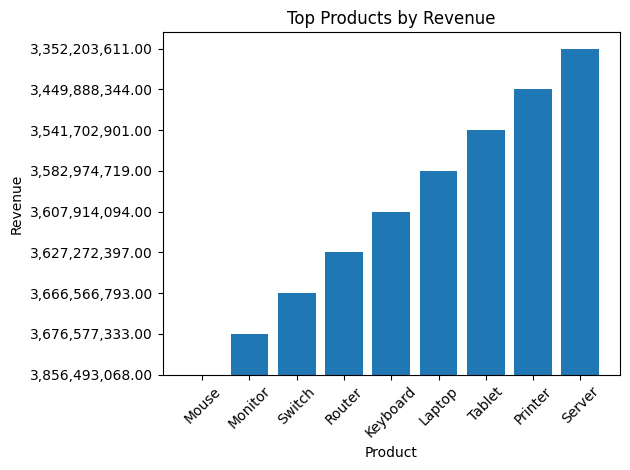

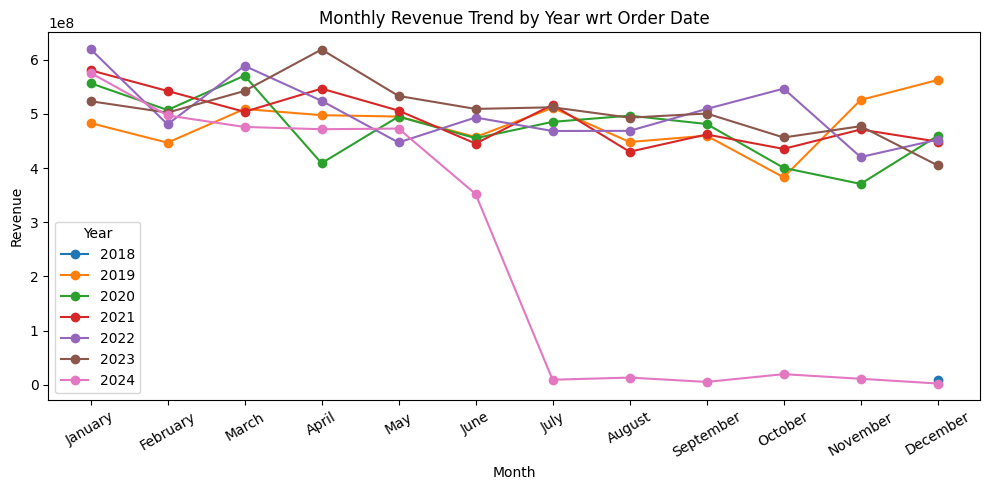

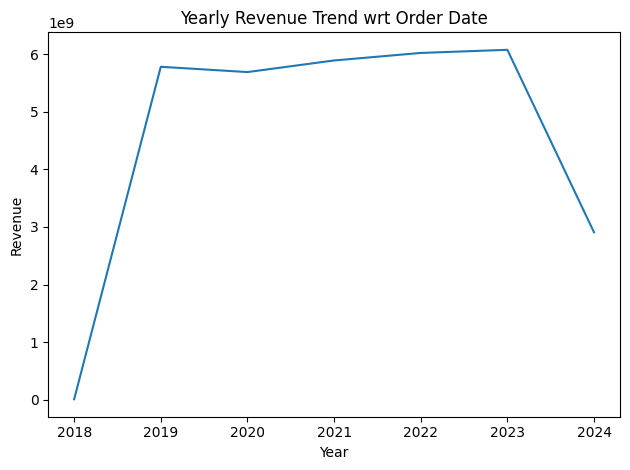

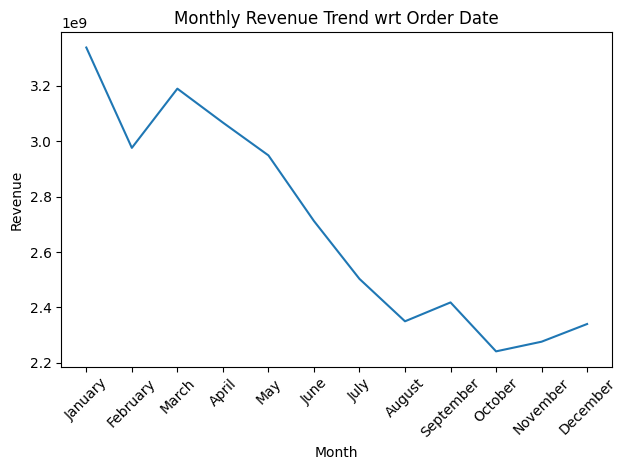

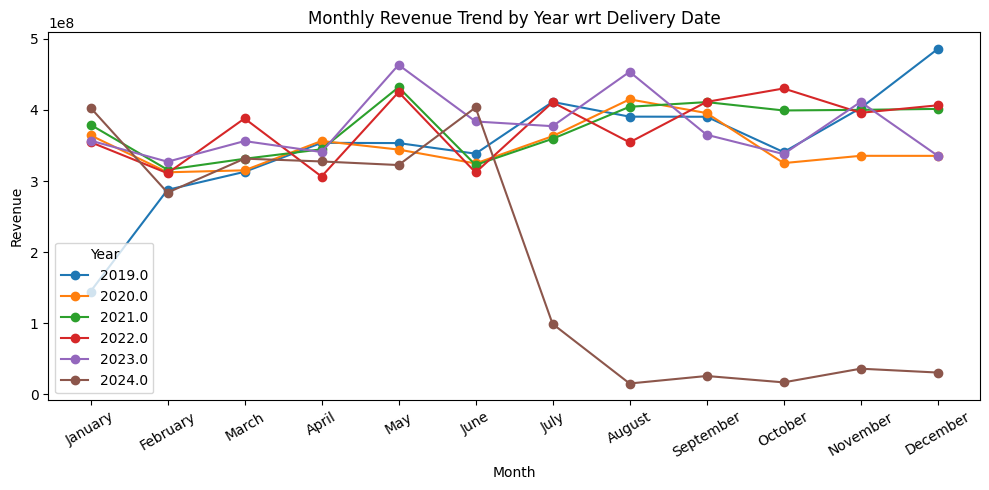

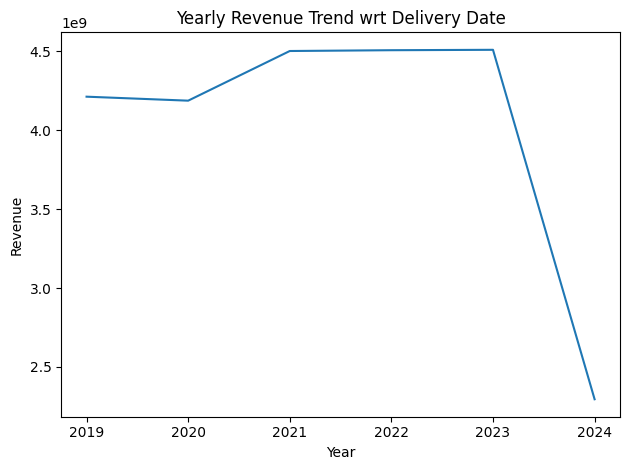

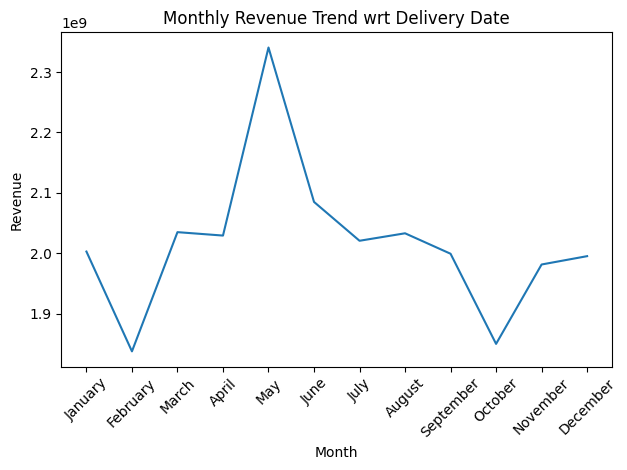

In [ ]:
# Visualization
import matplotlib.pyplot as plt
# Top Products Visualization
top5 = top_products
plt.figure()
plt.bar(top5['product_name'], top5['revenue'])
plt.xticks(rotation=45)
plt.title("Top Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# Monthly-Yearly Revenue Trend wrt Order Date
month_year_revenue_order = dataset.groupby(
    ['order_year', 'order_month', 'order_month_name']
)['revenue'].sum().reset_index()
month_year_revenue_order = month_year_revenue_order.sort_values(
    ['order_year', 'order_month']
)
# Create proper timeline
month_year_revenue_order['year_month'] = (
    month_year_revenue_order['order_year'].astype(str) + '-' +
    month_year_revenue_order['order_month'].astype(str)
)
# Pivot table (Month vs Year)
pivot_data = dataset.pivot_table(
    values='revenue',
    index='order_month_name',
    columns='order_year',
    aggfunc='sum'
)
# Correct month order
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
pivot_data = pivot_data.reindex(month_order)
# Plot
plt.figure(figsize=(10,5))
for year in pivot_data.columns:
    plt.plot(pivot_data.index, pivot_data[year], marker='o', label=year)
plt.title("Monthly Revenue Trend by Year wrt Order Date")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.legend(title="Year")
plt.tight_layout()
plt.show()

# Yearly Revenue wrt Order Date
# Group by year
yearly_revenue_order = dataset.groupby('order_year')['revenue'].sum().reset_index()
# Sort
yearly_revenue_order = yearly_revenue_order.sort_values('order_year')
# Plot
plt.figure()
plt.plot(yearly_revenue_order['order_year'], yearly_revenue_order['revenue'])
plt.title("Yearly Revenue Trend wrt Order Date")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.xticks(yearly_revenue_order['order_year'])
plt.tight_layout()
plt.show()

# Monthly Revenue wrt Order Date
# Group by month only
monthly_revenue_order = dataset.groupby(
    ['order_month', 'order_month_name']
)['revenue'].sum().reset_index()
# Sort by month number
monthly_revenue_order = monthly_revenue_order.sort_values('order_month')
# Plot
plt.figure()
plt.plot(
    monthly_revenue_order['order_month_name'],
    monthly_revenue_order['revenue']
)
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend wrt Order Date")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# Monthly_Yearly Revenue Trend wrt Delivery Date
month_year_revenue_delivery = dataset.groupby(
    ['delivery_year', 'delivery_month', 'delivery_month_name']
)['revenue'].sum().reset_index()
month_year_revenue_delivery = month_year_revenue_delivery.sort_values(
    ['delivery_year', 'delivery_month']
)
# Create proper timeline
month_year_revenue_delivery['year_month'] = (
    month_year_revenue_delivery['delivery_year'].astype(str) + '-' +
    month_year_revenue_delivery['delivery_month'].astype(str)
)
# Pivot table (Month vs Year)
pivot_data = dataset.pivot_table(
    values='revenue',
    index='delivery_month_name',
    columns='delivery_year',
    aggfunc='sum'
)
# Correct month order
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
pivot_data = pivot_data.reindex(month_order)
# Plot
plt.figure(figsize=(10,5))
for year in pivot_data.columns:
    plt.plot(pivot_data.index, pivot_data[year], marker='o', label=year)
plt.title("Monthly Revenue Trend by Year wrt Delivery Date")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.legend(title="Year")
plt.tight_layout()
plt.show()

# Yearly Revenue wrt Delivery Date
# Group by year
yearly_revenue_delivery = dataset.groupby('delivery_year')['revenue'].sum().reset_index()
# Sort
yearly_revenue_delivery = yearly_revenue_delivery.sort_values('delivery_year')
# Plot
plt.figure()
plt.plot(yearly_revenue_delivery['delivery_year'], yearly_revenue_delivery['revenue'])
plt.title("Yearly Revenue Trend wrt Delivery Date")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.xticks(yearly_revenue_delivery['delivery_year'])
plt.tight_layout()
plt.show()

# Monthly Revenue wrt Delivery Date
monthly_revenue_delivery_simple = dataset.groupby(
    ['delivery_month', 'delivery_month_name']
)['revenue'].sum().reset_index()
monthly_revenue_delivery_simple = monthly_revenue_delivery_simple.sort_values('delivery_month')
plt.figure()
plt.plot(
    monthly_revenue_delivery_simple['delivery_month_name'],
    monthly_revenue_delivery_simple['revenue']
)
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend wrt Delivery Date")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

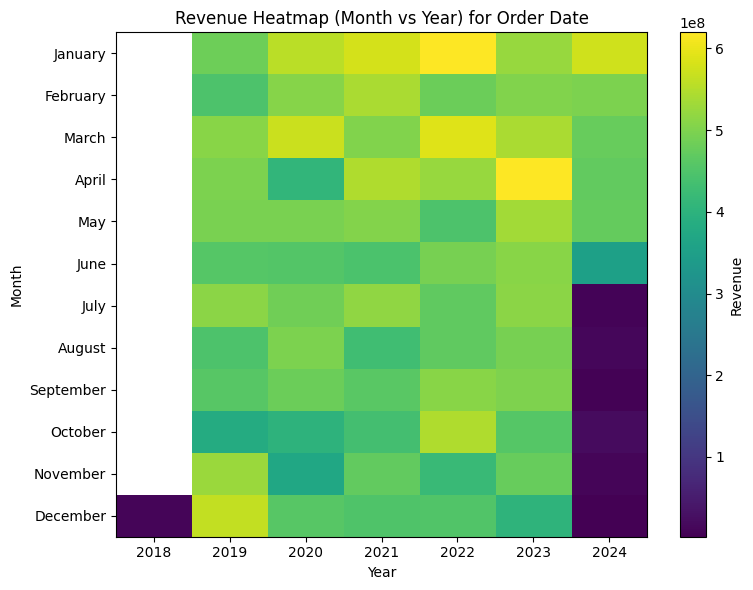

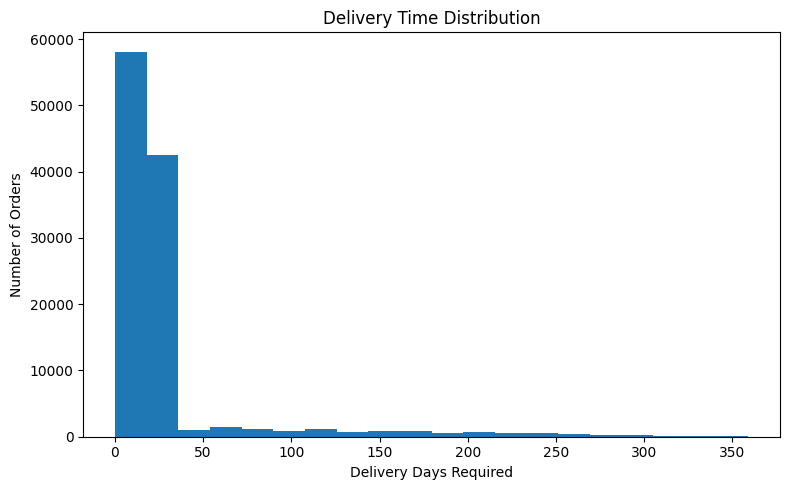

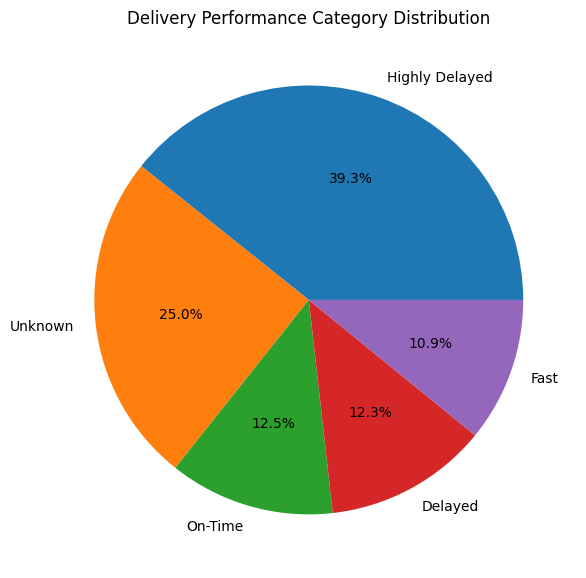

In [ ]:
# Advanced Visualization
import matplotlib.pyplot as plt
import pandas as pd
# Month vs Year Revenue (Heatmap) for Order date
# Pivot table (Year vs Month)
heatmap_data = dataset.pivot_table(
    values='revenue',
    index='order_month_name',
    columns='order_year',
    aggfunc='sum'
)
# Reorder months correctly
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
heatmap_data = heatmap_data.reindex(month_order)
# Plot
plt.figure(figsize=(8,6))
plt.imshow(heatmap_data, aspect='auto')
plt.colorbar(label='Revenue')
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.title("Revenue Heatmap (Month vs Year) for Order Date")
plt.xlabel("Year")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

# Delivery Performance Distribution (Histogram)
plt.figure(figsize=(8,5))
plt.hist(dataset['delivery_days_required'].dropna(), bins=20)
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days Required")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

# Delivery Performance wrt Category
def delay_category(days):
    if pd.isna(days):
        return 'Unknown'
    elif days <= 3:
        return 'Fast'
    elif days <= 7:
        return 'On-Time'
    elif days <= 15:
        return 'Delayed'
    else:
        return 'Highly Delayed'
dataset['delivery_status'] = dataset['delivery_days_required'].apply(delay_category)
category_count = dataset['delivery_status'].value_counts()
# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    category_count.values,
    labels=category_count.index,
    autopct='%1.1f%%'
)
plt.title("Delivery Performance Category Distribution")
plt.tight_layout()
plt.show()

In [ ]:
# Advanced Data Cleaning
# Handle missing values in order status based on delivery timelines
dataset['order_status_new'] = dataset['order_status']
mask = (
    (dataset['order_status'] == 'NA') &
    dataset['order_date'].notnull() &
    dataset['delivery_date'].notnull() &
    dataset['delivery_days_required'].notnull()
)

# Apply business logic
dataset.loc[mask & (dataset['delivery_days_required'] <= 3), 'order_status_new'] = 'Completed'
dataset.loc[mask & (dataset['delivery_days_required'] > 3) & (dataset['delivery_days_required'] <= 7), 'order_status_new'] = 'Pending'
dataset.loc[mask & (dataset['delivery_days_required'] > 7), 'order_status_new'] = 'Cancelled'

# Result
print("Original Order Status Count:")
print(dataset['order_status'].value_counts())
print("\nNew Order Status Count:")
print(dataset['order_status_new'].value_counts())

# Updated data sample
changed = dataset[dataset['order_status'] != dataset['order_status_new']]
print("\nOrder Status Updated Records:", changed.shape[0])
print(changed[['order_status', 'order_status_new']])

Original Order Status Count:
order_status
Cancelled    37595
Completed    37568
NA           37505
Pending      37332
Name: count, dtype: int64

New Order Status Count:
order_status_new
Cancelled    56806
Pending      42023
Completed    41707
NA            9464
Name: count, dtype: int64

Order Status Updated Records: 28041
       order_status order_status_new
0                NA        Cancelled
7                NA        Completed
9                NA        Cancelled
20               NA        Completed
24               NA        Cancelled
...             ...              ...
149960           NA        Cancelled
149967           NA        Cancelled
149984           NA        Completed
149986           NA        Completed
149998           NA        Cancelled

[28041 rows x 2 columns]


In [ ]:
# Fill quantity using mean per product
# Store original nulls
qty_null_mask = dataset['quantity'].isna()
# Calculate product-wise mean
qty_mean = dataset.groupby('product_name')['quantity'].mean()
# Create rounded mean
qty_mean_rounded = qty_mean.round(0).astype(int)
# Display both
qty_mean_df = qty_mean.to_frame(name='Original_Mean')
qty_mean_df['Rounded_Mean'] = qty_mean_rounded
# Create new column
dataset['quantity_new'] = dataset['quantity']
# Handle Quantity = 0 when Order Status = COmpleted / Pending as again Mean
# Zero Count Before
zero_before = (
    (dataset['quantity_new'] == 0) &
    (dataset['order_status_new'].isin(['Completed', 'Pending']))
).sum()
print("Zero Quantity Count:")
print("Zero Quantity Count Before:", zero_before)
# Before Status-wise
zero_status_before = dataset[
    (dataset['quantity_new'] == 0) &
    (dataset['order_status_new'].isin(['Completed', 'Pending']))
]['order_status_new'].value_counts()
print("Zero Quantity Before (Status-wise):")
print(zero_status_before)
# Condition: quantity = 0 AND valid order status
mask_zero = (
    (dataset['quantity_new'] == 0) &
    (dataset['order_status_new'].isin(['Completed', 'Pending']))
)
# Fill 0 values
dataset.loc[mask_zero, 'quantity_new'] = \
    dataset.loc[mask_zero, 'product_name'].map(qty_mean_rounded)
# Zero Count After
zero_after = (
    (dataset['quantity_new'] == 0) &
    (dataset['order_status_new'].isin(['Completed', 'Pending']))
).sum()
print("\nZero Quantity Count After:", zero_after)
# After Status-wise
zero_status_after = dataset[
    (dataset['quantity_new'] == 0) &
    (dataset['order_status_new'].isin(['Completed', 'Pending']))
]['order_status_new'].value_counts()
print("Zero Quantity After (Status-wise):")
print(zero_status_after)
# Final Count how many corrected
zero_fixed_count = mask_zero.sum()
print("Zero Quantity Corrected Count:", zero_fixed_count)
# Fill NA using rounded mean
dataset.loc[dataset['quantity_new'].isna(), 'quantity_new'] = \
    dataset.loc[dataset['quantity_new'].isna(), 'product_name'].map(qty_mean_rounded)
# Convert to integer (important)
dataset['quantity_new'] = dataset['quantity_new'].astype('Int64')
# Count filled per product
qty_filled = dataset[qty_null_mask].groupby('product_name')['quantity_new'].count()
print("\nQuantity Mean per Product:")
print(qty_mean_df)
print("\nQuantity Filled Count per Product:")
print(qty_filled)

# Fill unit_price using mean per product + supplier
# Store original nulls
price_null_mask = dataset['unit_price'].isna()
# Calculate product + supplier mean
price_mean_ps = dataset.groupby(['product_name', 'supplier'])['unit_price'].mean()
# Create new column
dataset['unit_price_new'] = dataset['unit_price']
# Fill
dataset['unit_price_new'] = dataset.groupby(['product_name', 'supplier'])['unit_price_new'].transform(
    lambda x: x.fillna(x.mean())
)
# Count filled
price_filled_ps = dataset[price_null_mask & dataset['unit_price_new'].notna()] \
    .groupby(['product_name', 'supplier'])['unit_price_new'].count()
print("\nUnit Price Mean (Product + Supplier):")
print(price_mean_ps)
print("\nUnit Price Filled Count (Product + Supplier):")
print(price_filled_ps)
# Fallback 1: product-wise mean (product given but supplier missing so product average)
# Store nulls after step 1
price_null_after_ps = dataset['unit_price_new'].isna()
# Fill
dataset['unit_price_new'] = dataset['unit_price_new'].fillna(
    dataset.groupby('product_name')['unit_price_new'].transform('mean')
)
# Count filled
price_filled_ps = dataset[price_null_mask & dataset['unit_price_new'].notna()] \
    .groupby(['product_name', 'supplier'])['unit_price'].count()
print("\nUnit Price Mean (Product + Supplier) when Supplier is NA:")
print(price_mean_ps)
print("\nUnit Price Filled Count (Product + Supplier) when Supplier is Empty:")
print(price_filled_ps)
# Fallback 2: overall mean (both product and supplier missing so overall dataset average)
# Store nulls after fallback 1
price_null_after_p = dataset['unit_price_new'].isna()
# Fill
dataset['unit_price_new'] = dataset['unit_price_new'].fillna(dataset['unit_price_new'].mean())
# Count filled
filled_overall = dataset[price_null_after_p & dataset['unit_price_new'].notna()].shape[0]
print("\nFilled using Overall Mean when both Product & Supplier is Empty:", filled_overall)

Zero Quantity Count:
Zero Quantity Count Before: 20850
Zero Quantity Before (Status-wise):
order_status_new
Pending      10569
Completed    10281
Name: count, dtype: int64

Zero Quantity Count After: 0
Zero Quantity After (Status-wise):
Series([], Name: count, dtype: int64)
Zero Quantity Corrected Count: 20850

Quantity Mean per Product:
              Original_Mean  Rounded_Mean
product_name                             
Keyboard              21.58            22
Laptop                21.07            21
Monitor               21.04            21
Mouse                 20.91            21
Printer               21.52            22
Router                21.36            21
Server                21.00            21
Switch                21.58            22
Tablet                20.85            21

Quantity Filled Count per Product:
product_name
Keyboard    4127
Laptop      4116
Monitor     4183
Mouse       4276
Printer     4106
Router      4308
Server      4114
Switch      4132
Tablet      4

In [ ]:
dataset.head(50)

,order_id,customer_id,product_name,supplier,city,order_date,delivery_date,quantity,unit_price,order_status,...,order_day,delivery_year,delivery_month,delivery_month_name,delivery_day,delivery_days_required,delivery_status,order_status_new,quantity_new,unit_price_new
0,0,3995,Switch,Supplyhub,Mumbai,25-10-2020,12-11-2020,84.00,NaN,NA,...,25,2020.00,11.00,November,12.00,18.00,Highly Delayed,Cancelled,84,40942.78
1,1,2828,Server,Techsupply,Chennai,24-05-2019,NaN,NaN,NaN,Cancelled,...,24,NaN,NaN,NaN,NaN,NaN,Unknown,Cancelled,21,41124.92
2,ORD2,NaN,Mouse,Globalsupply,Delhi,16-08-2020,12-09-2020,3.00,NaN,Completed,...,16,2020.00,9.00,September,12.00,27.00,Highly Delayed,Completed,3,40198.45
3,NaN,3962,Keyboard,Supplyhub,Delhi,21-06-2022,NaN,NaN,NaN,Pending,...,21,NaN,NaN,NaN,NaN,NaN,Unknown,Pending,22,40133.58
4,4,CUST5193,Keyboard,Globalsupply,Pune,11-12-2021,25-12-2021,NaN,NaN,Completed,...,11,2021.00,12.00,December,25.00,14.00,Delayed,Completed,22,41070.73
5,NaN,NaN,Router,Globaltech,Delhi,24-05-2024,21-06-2024,3.00,NaN,Pending,...,24,2024.00,6.00,June,21.00,28.00,Highly Delayed,Pending,3,41190.02
6,NaN,CUST1184,Tablet,Itsource,Bengaluru,05-05-2019,17-05-2019,NaN,NaN,Completed,...,5,2019.00,5.00,May,17.00,12.00,Delayed,Completed,21,41067.75
7,NaN,CUST2362,Server,Techsupply,Pune,22-03-2020,23-03-2020,0.00,NaN,NA,...,22,2020.00,3.00,March,23.00,1.00,Fast,Completed,21,41124.92
8,ORD8,2900,Router,Itsource,Bengaluru,04-01-2021,21-01-2021,0.00,11376.00,Cancelled,...,4,2021.00,1.00,January,21.00,17.00,Highly Delayed,Cancelled,0,11376.00
9,9,CUST5581,Server,Itsource,Kolkata,08-05-2021,09-06-2021,3.00,NaN,NA,...,8,2021.00,6.00,June,9.00,32.00,Highly Delayed,Cancelled,3,40093.16


In [ ]:
# Create Revenue column for new quantity & unit price
dataset['revenue_new'] = dataset['quantity_new'] * dataset['unit_price_new']
print("Updated Revenue:")
print(dataset[['quantity_new', 'unit_price_new', 'revenue_new']])
dataset.head(50)

Updated Revenue:
        quantity_new  unit_price_new  revenue_new
0                 84        40942.78   3439193.78
1                 21        41124.92    863623.38
2                  3        40198.45    120595.36
3                 22        40133.58    882938.84
4                 22        41070.73    903555.95
...              ...             ...          ...
149995            96         6338.00    608448.00
149996            33        40753.67   1344871.02
149997            21        41595.88    873513.54
149998            21        46864.00    984144.00
149999            25        43042.00   1076050.00

[150000 rows x 3 columns]


,order_id,customer_id,product_name,supplier,city,order_date,delivery_date,quantity,unit_price,order_status,...,delivery_year,delivery_month,delivery_month_name,delivery_day,delivery_days_required,delivery_status,order_status_new,quantity_new,unit_price_new,revenue_new
0,0,3995,Switch,Supplyhub,Mumbai,25-10-2020,12-11-2020,84.00,NaN,NA,...,2020.00,11.00,November,12.00,18.00,Highly Delayed,Cancelled,84,40942.78,3439193.78
1,1,2828,Server,Techsupply,Chennai,24-05-2019,NaN,NaN,NaN,Cancelled,...,NaN,NaN,NaN,NaN,NaN,Unknown,Cancelled,21,41124.92,863623.38
2,ORD2,NaN,Mouse,Globalsupply,Delhi,16-08-2020,12-09-2020,3.00,NaN,Completed,...,2020.00,9.00,September,12.00,27.00,Highly Delayed,Completed,3,40198.45,120595.36
3,NaN,3962,Keyboard,Supplyhub,Delhi,21-06-2022,NaN,NaN,NaN,Pending,...,NaN,NaN,NaN,NaN,NaN,Unknown,Pending,22,40133.58,882938.84
4,4,CUST5193,Keyboard,Globalsupply,Pune,11-12-2021,25-12-2021,NaN,NaN,Completed,...,2021.00,12.00,December,25.00,14.00,Delayed,Completed,22,41070.73,903555.95
5,NaN,NaN,Router,Globaltech,Delhi,24-05-2024,21-06-2024,3.00,NaN,Pending,...,2024.00,6.00,June,21.00,28.00,Highly Delayed,Pending,3,41190.02,123570.05
6,NaN,CUST1184,Tablet,Itsource,Bengaluru,05-05-2019,17-05-2019,NaN,NaN,Completed,...,2019.00,5.00,May,17.00,12.00,Delayed,Completed,21,41067.75,862422.76
7,NaN,CUST2362,Server,Techsupply,Pune,22-03-2020,23-03-2020,0.00,NaN,NA,...,2020.00,3.00,March,23.00,1.00,Fast,Completed,21,41124.92,863623.38
8,ORD8,2900,Router,Itsource,Bengaluru,04-01-2021,21-01-2021,0.00,11376.00,Cancelled,...,2021.00,1.00,January,21.00,17.00,Highly Delayed,Cancelled,0,11376.00,0.00
9,9,CUST5581,Server,Itsource,Kolkata,08-05-2021,09-06-2021,3.00,NaN,NA,...,2021.00,6.00,June,9.00,32.00,Highly Delayed,Cancelled,3,40093.16,120279.48


In [ ]:
dataset.isnull().sum()

,0
order_id,74711
customer_id,49732
product_name,0
supplier,0
city,0
order_date,0
delivery_date,37556
quantity,37509
unit_price,99802
order_status,0


In [ ]:
# Handling Order_ID & Customer_ID
# Create cleaned copies
dataset['order_id_clean'] = dataset['order_id']
dataset['customer_id_clean'] = dataset['customer_id']

# Standardize ID Format
# order_id_clean
dataset['order_id_clean'] = dataset['order_id_clean'].apply(
    lambda x: f"ORD{int(x)}" if pd.notnull(x) and str(x).isdigit() else x
)
# customer_id_clean
dataset['customer_id_clean'] = dataset['customer_id_clean'].apply(
    lambda x: f"CUST{int(x)}" if pd.notnull(x) and str(x).isdigit() else x
)

# Fill Missing customer_id (group logic)
dataset['customer_id_clean'] = dataset.groupby('order_id_clean')['customer_id_clean'].transform(
    lambda x: x.ffill().bfill()
)
# Final fallback for remaining NULLs
nan_cust_mask = dataset['customer_id_clean'].isnull()
dataset.loc[nan_cust_mask, 'customer_id_clean'] = \
    'CUST' + (dataset.index[nan_cust_mask] + 50000).astype(str)

# Fill Missing order_id
nan_order_mask = dataset['order_id_clean'].isnull()
dataset.loc[nan_order_mask, 'order_id_clean'] = \
    'ORD' + (dataset.index[nan_order_mask] + 10000).astype(str)

# Final Validation
print("Cleaned dataset:")
print(dataset[['order_id', 'order_id_clean', 'customer_id', 'customer_id_clean']].head(50))
print("\nMissing Clean Order ID:", dataset['order_id_clean'].isnull().sum())
print("Missing Clean Customer ID:", dataset['customer_id_clean'].isnull().sum())

/tmp/ipykernel_10104/2940710871.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.ffill().bfill()


Cleaned dataset:
   order_id order_id_clean customer_id customer_id_clean
0         0           ORD0        3995          CUST3995
1         1           ORD1        2828          CUST2828
2      ORD2           ORD2         NaN         CUST50002
3       NaN       ORD10003        3962         CUST50003
4         4           ORD4    CUST5193          CUST5193
5       NaN       ORD10005         NaN         CUST50005
6       NaN       ORD10006    CUST1184         CUST50006
7       NaN       ORD10007    CUST2362         CUST50007
8      ORD8           ORD8        2900          CUST2900
9         9           ORD9    CUST5581          CUST5581
10      NaN       ORD10010        5921         CUST50010
11      NaN       ORD10011    CUST5933         CUST50011
12      NaN       ORD10012         NaN         CUST50012
13      NaN       ORD10013        2368         CUST50013
14       14          ORD14    CUST3288          CUST3288
15    ORD15          ORD15    CUST2674          CUST2674
16      NaN   

In [ ]:
# Save preprocessed file
dataset.to_csv("Profiling_ERP_Dataset_1.csv", index=False)
# Download preprocessed file
files.download("Profiling_ERP_Dataset_1.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(dataset['order_status_new'].value_counts())

order_status_new
Cancelled    56806
Pending      42023
Completed    41707
NA            9464
Name: count, dtype: int64
